In [1]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
class DQDVDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = [f for f in os.listdir(root_dir) if f.endswith('.png')]
        self.samples.sort()  # 順番を固定

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        png_name = self.samples[idx]
        base_name = os.path.splitext(png_name)[0]
        img_path = os.path.join(self.root_dir, f"{base_name}.png")
        label_path = os.path.join(self.root_dir, f"{base_name}_label.csv")

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        label_df = pd.read_csv(label_path)
        label = torch.tensor(label_df.values[0], dtype=torch.float32)

        return image, label

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [5]:
batch_size = 128
data_root = "D:/Yamato/dQdV"

datasets = {
    split: DQDVDataset(os.path.join(data_root, split), transform=transform)
    for split in ['Train', 'Val', 'Test']
}
dataloaders = {
    split: DataLoader(datasets[split], batch_size=batch_size, shuffle=(split=='Train'))
    for split in ['Train', 'Val', 'Test']
}


In [6]:
# === モデル構築 ===
model = models.resnet50(pretrained=True)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 7),  # 7ラベル
    nn.Sigmoid()
)
model = model.to(device)

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\anaconda3\envs\nn\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
# === 学習ループ ===
num_epochs = 100
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    for phase in ['Train', 'Val']:
        if phase == 'Train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        all_preds = []
        all_labels = []

        for inputs, labels in tqdm(dataloaders[phase]):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = (outputs > 0.5).int().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

        save_path = "ResNet50_dqdv_classifier.pth"
        torch.save(model.state_dict(), save_path)
        epoch_loss = running_loss / len(datasets[phase])
        epoch_f1 = f1_score(all_labels, all_preds, average='micro')
        print(f"{phase} Loss: {epoch_loss:.4f} F1: {epoch_f1:.4f}")

Epoch 1/100


100%|██████████████████████████████████████████████████████████████████████████████████| 28/28 [01:03<00:00,  2.28s/it]


Train Loss: 0.5204 F1: 0.6660


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.92s/it]


Val Loss: 0.6452 F1: 0.5760
Epoch 2/100


...

Train Loss: 0.0095 F1: 0.9974


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.23it/s]


Val Loss: 1.0048 F1: 0.7257
Epoch 46/100


 75%|█████████████████████████████████████████████████████████████▌                    | 21/28 [00:22<00:07,  1.06s/it]


KeyboardInterrupt: 

In [10]:
# === テスト精度評価 ===
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, hamming_loss
import numpy as np

# === テスト精度評価 ===
model.load_state_dict(torch.load("ResNet50_dqdv_classifier.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['Test']):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = (outputs > 0.5).int().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# numpy配列に変換
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# === 各種評価指標 ===
f1_micro = f1_score(all_labels, all_preds, average='micro')
f1_macro = f1_score(all_labels, all_preds, average='macro')
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
subset_acc = accuracy_score(all_labels, all_preds)
hamming = hamming_loss(all_labels, all_preds)

# === 表示 ===
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"Subset Accuracy: {subset_acc:.4f}")
print(f"Hamming Loss: {hamming:.4f}")

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:06<00:00,  1.18it/s]

F1 Score (micro): 0.7311
F1 Score (macro): 0.7321
Precision (macro): 0.7412
Recall (macro): 0.7263
Subset Accuracy: 0.0730
Hamming Loss: 0.2677


In [16]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

    def generate(self, input_tensor, target_class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[:, target_class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # グローバル平均
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (input_tensor.shape[2], input_tensor.shape[3]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def visualize_multiple_gradcams(model, dataloader, device, target_class_idx=0, num_images=5):
    model.eval()
    grad_cam = GradCAM(model, model.layer4)

    data_iter = iter(dataloader)
    for i in range(num_images):
        try:
            inputs, labels = next(data_iter)
        except StopIteration:
            break  # データ終わり

        inputs = inputs.to(device)
        labels = labels.to(device)
        img_tensor = inputs[0].unsqueeze(0)  # 1枚だけ
        true_label = labels[0].cpu().numpy()

        # 推論
        with torch.no_grad():
            outputs = model(img_tensor)
            probs = outputs.cpu().numpy()[0]
            preds = (probs > 0.5).astype(int)

        # Grad-CAM取得
        cam = grad_cam.generate(img_tensor, target_class_idx)

        # 元画像表示用変換
        img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = heatmap[..., ::-1] / 255.0
        superimposed_img = heatmap * 0.4 + img_np * 0.6

        plt.figure(figsize=(14, 5))
        plt.subplot(1, 4, 1)
        plt.title(f"Image {i+1} Original")
        plt.imshow(img_np)
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title(f"Grad-CAM Label {target_class_idx}")
        plt.imshow(cam, cmap="jet")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        # plt.title("Overlay")
        plt.imshow(superimposed_img)
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.axis("off")
        true_val = true_label[target_class_idx]
        pred_val = preds[target_class_idx]
        plt.text(0, 0.6, f"True Label: {true_val}", fontsize=14)
        plt.text(0, 0.4, f"Pred Label: {pred_val}", fontsize=14)
        plt.text(0, 0.2, f"Prob: {probs[target_class_idx]:.3f}", fontsize=14)

        plt.tight_layout()
        plt.show()

    grad_cam.remove_hooks()


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


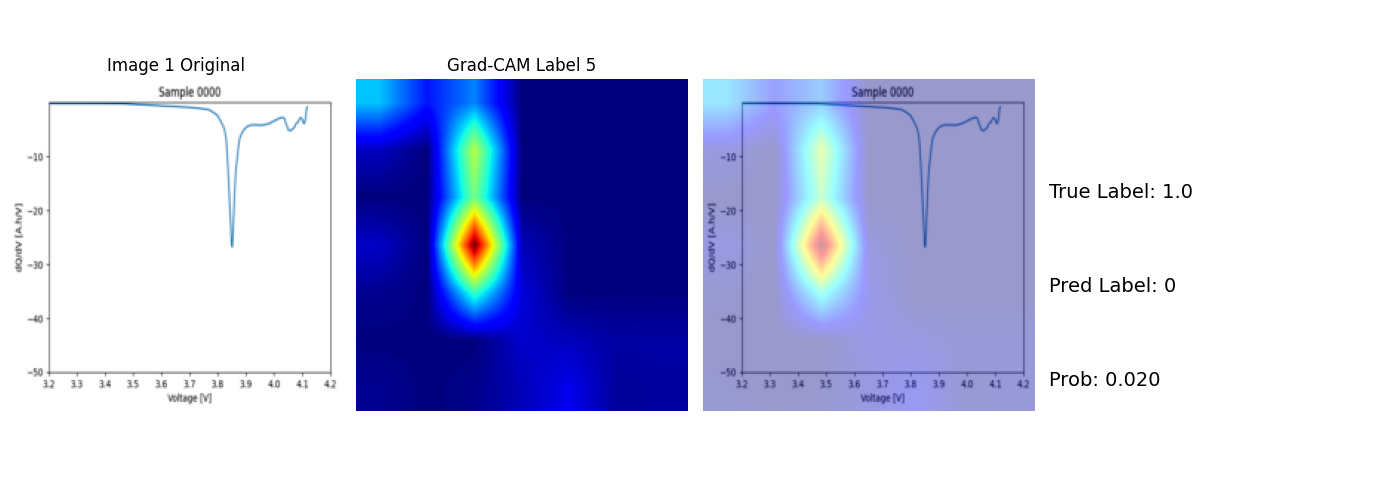

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


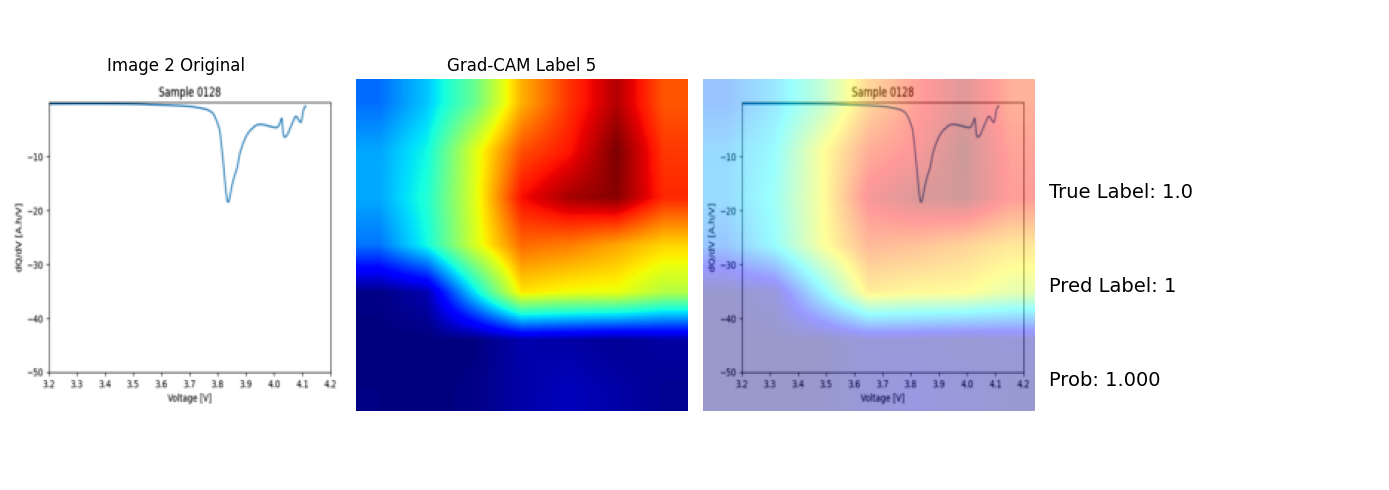

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


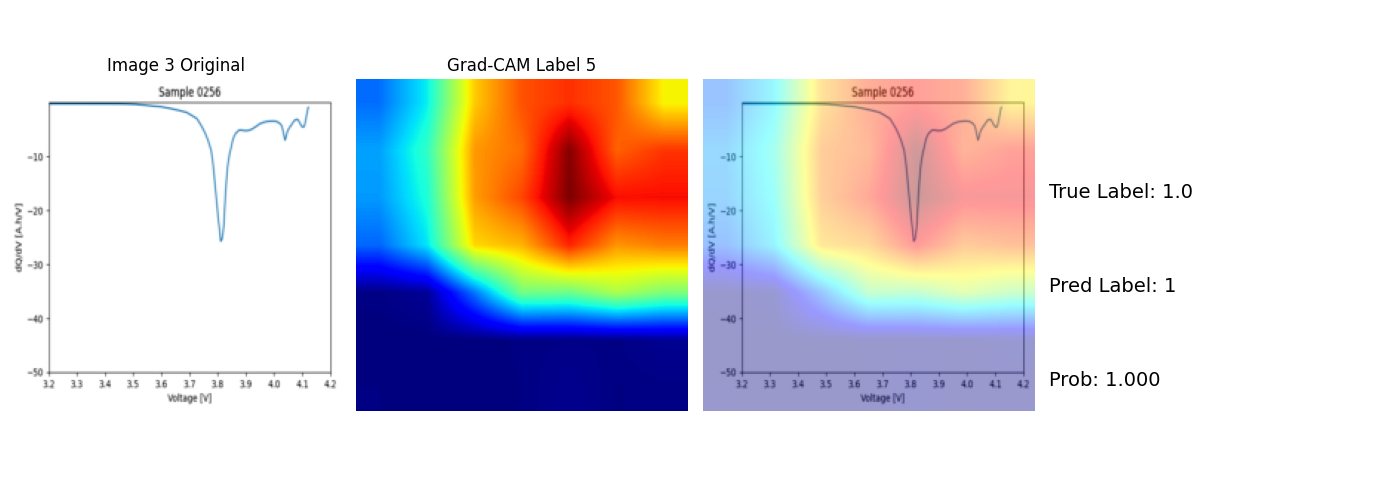

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


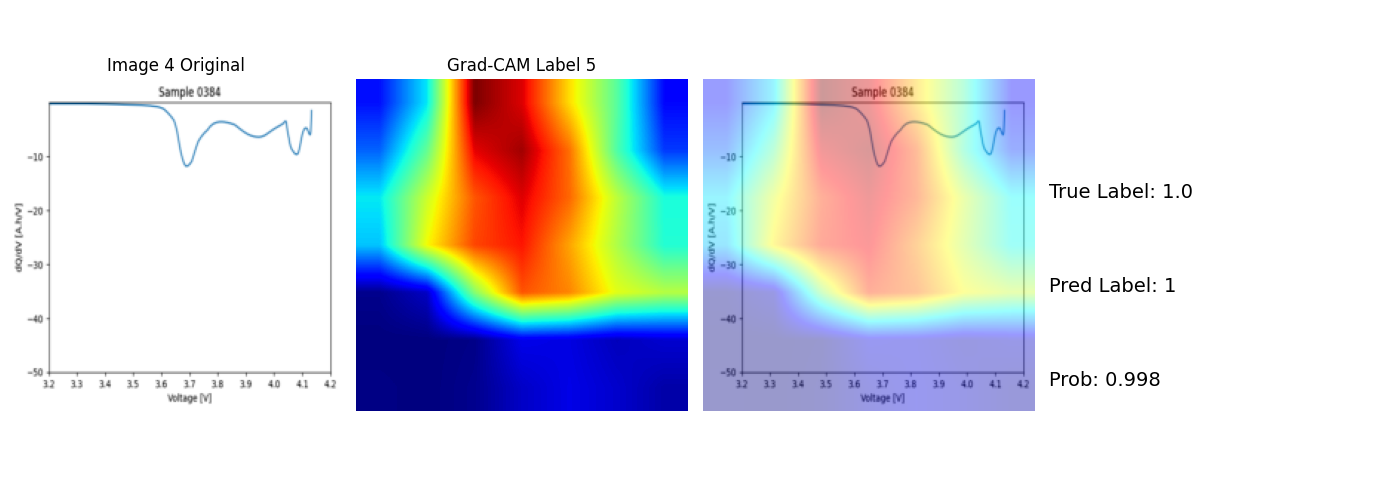

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


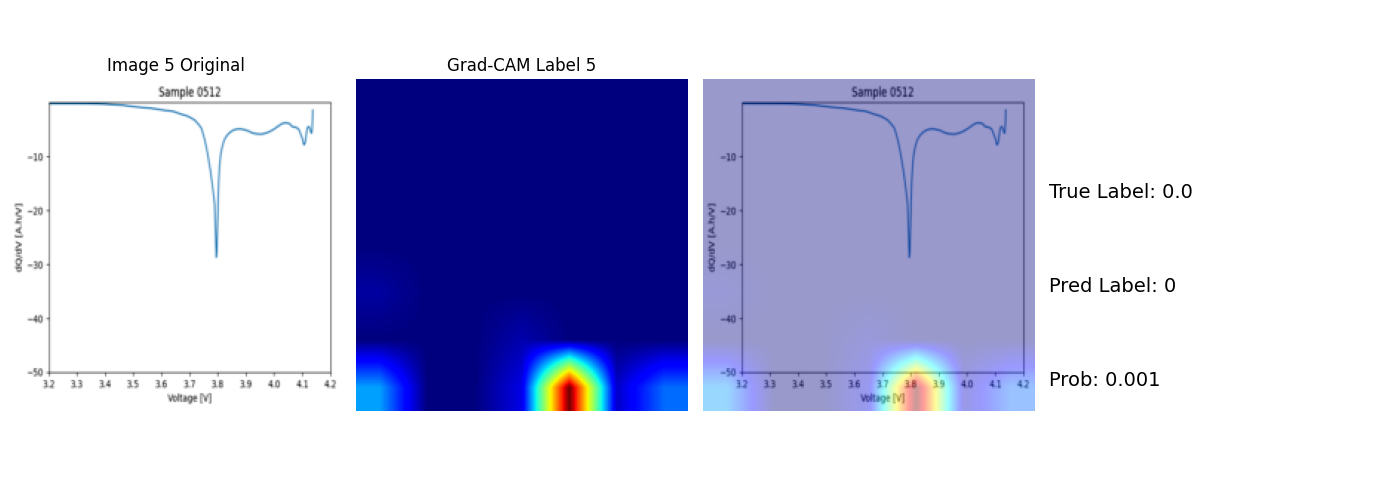

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


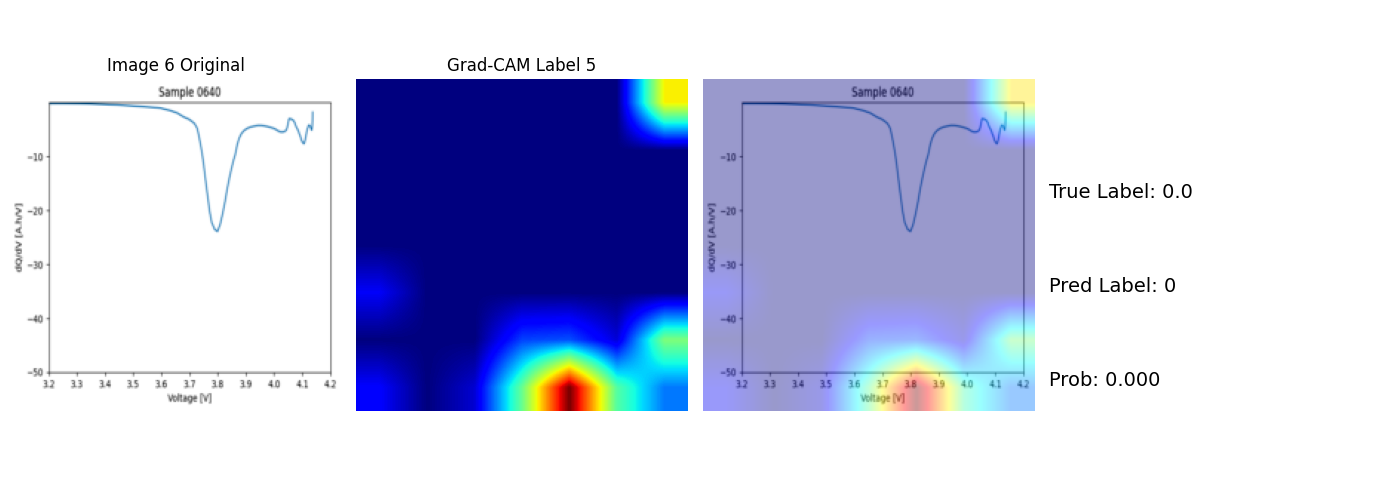

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


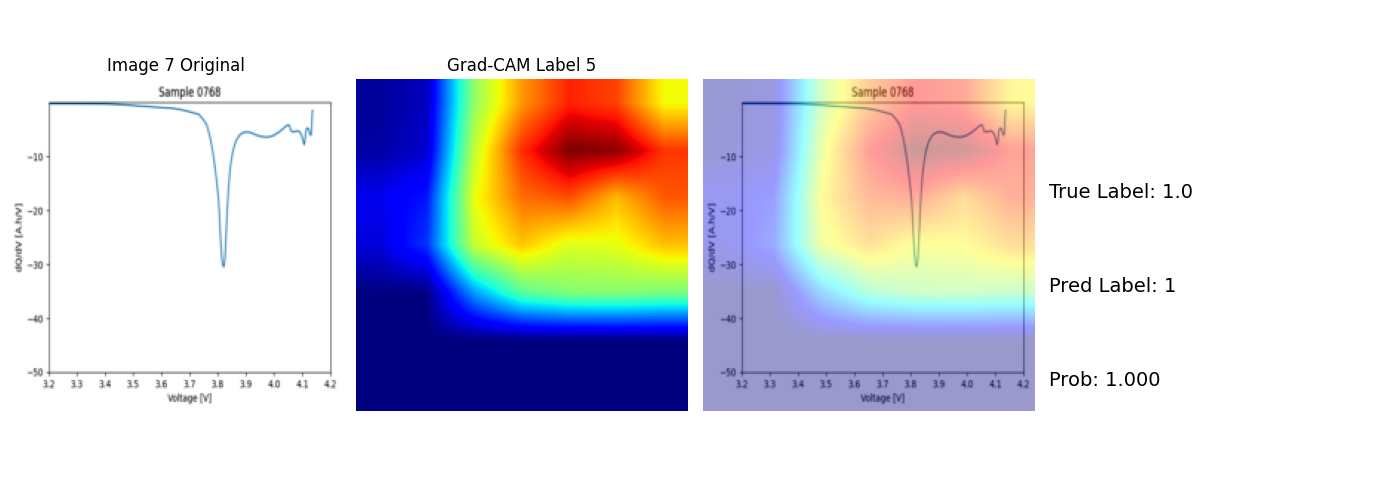

C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\nn\modules\module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


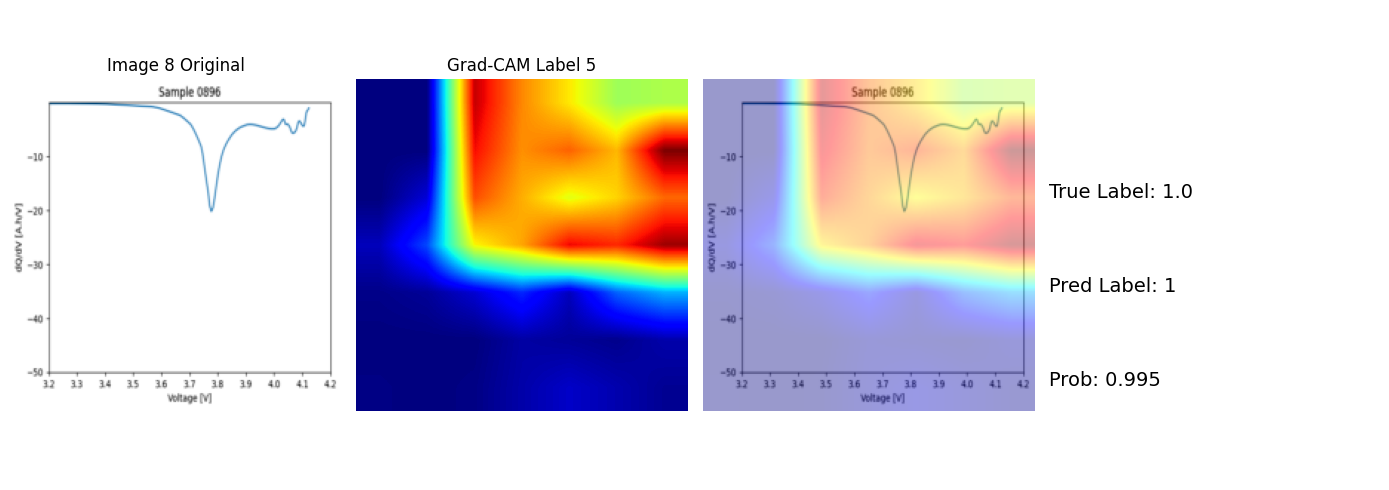

In [18]:
visualize_multiple_gradcams(model, dataloaders['Test'], device, target_class_idx=5, num_images=100)


In [15]:
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['Test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = (outputs > 0.5).int()  # バイナリ化
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)  # (N, 7)
all_labels = np.vstack(all_labels)  # (N, 7)

# 各ラベルごとの正答率を計算
accuracies = np.mean(all_preds == all_labels, axis=0)  # ラベル軸ごとに一致率

for i, acc in enumerate(accuracies):
    print(f"Label {i}: Accuracy = {acc:.4f}")


Label 0: Accuracy = 0.4770
Label 1: Accuracy = 0.4790
Label 2: Accuracy = 0.5290
Label 3: Accuracy = 0.9930
Label 4: Accuracy = 0.9980
Label 5: Accuracy = 0.9140
Label 6: Accuracy = 0.7360
